In [1]:
import mesa_reader as mr

In [2]:
logs = mr.MesaLogDir("LOGS")
h = logs.history


In [3]:
import matplotlib.pyplot as plt

for i in range(1, 12):
    p = logs.profile_data(profile_number=i)
    fig = plt.figure()
    ax = fig.add_subplot(121)
    ax.loglog(p.radius, p.T, label="T")
    ax.loglog(p.radius, p.Rho, label=r"$\rho$")
    ax.set_ylim(1.e0,)
    ax.set_title(f"{i}")
    ax.legend()

    ax2 = fig.add_subplot(122)
    ax2.loglog(p.radius, p.eps_nuc)

    fig.set_size_inches(10, 6)
    fig.tight_layout()

we'll use profile 8, since that seems to be the most energetic

In [4]:
model = logs.profile_data(profile_number=8)

In [5]:
from pynucastro import mesa_utils
import pynucastro as pyna

In [6]:
nuclei = mesa_utils.get_nuclei(model)

In [7]:
mm = mesa_utils.MesaModel(model)

find the zone with highest T

In [8]:
idx = mm.get_peak_index("T")
idx

np.int64(570)

In [9]:
net = pyna.network_helper(nuclei, tabular_ordering=["ffn", "oda"])

In [10]:
mesa_state = mm.get_zone_data(idx)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 b

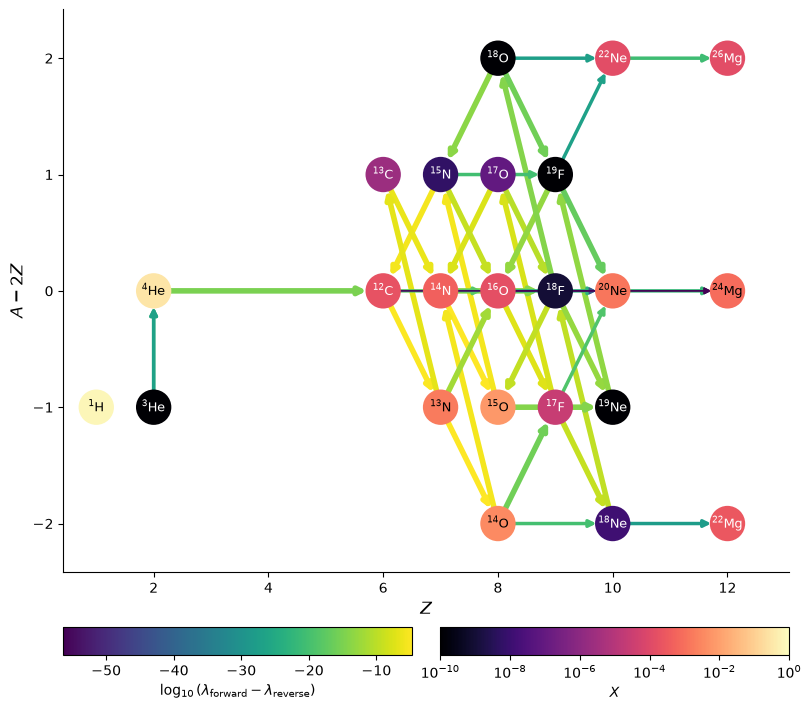

In [11]:
fig = net.plot(mesa_state.rho, mesa_state.T, mesa_state.comp, rotated=True,
               use_net_rate=True,
               size=(800, 700),
               node_size=550, node_font_size=9,
               color_nodes_by_abundance=True)

In [12]:
fig.savefig("mesa-nova.pdf", bbox_inches="tight")

In [13]:
rho = mm.get_data_array("rho")
T = mm.get_data_array("T")
r = mm.get_data_array("r")

In [14]:
rho.shape

(1483,)

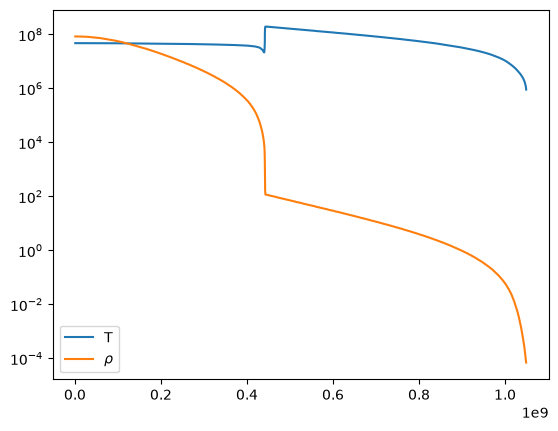

In [15]:
fig, ax = plt.subplots()
ax.semilogy(r, T, label="T")
ax.semilogy(r, rho, label=r"$\rho$")
ax.legend()